# 1. Import librarys

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import SGD

In [3]:
import warnings
warnings.filterwarnings('ignore')

# 2. Insert stonk data

In [4]:
def yf_stock(ticker, start_date='2018-01-01', end_date='2022-12-31'):
    df = yf.download(ticker, start=start_date, end=end_date)
    df = df.dropna()
    df = df[['Open', 'Close', 'Low', 'High']]
    return df

In [5]:
def show_plt(df, names, title='Stock Prices', colors=['g', 'b', 'r', 'c', 'm']):
    plt.figure(figsize=(12,6))
    for i, name in enumerate(names):
        plt.plot(df[name], color=colors[i % len(colors)], label={name})
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Close price')

    plt.legend()
    plt.show()

In [6]:
stock_raw_data = yf_stock('GOOG')
stock_raw_data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Open,Close,Low,High
Ticker,GOOG,GOOG,GOOG,GOOG
Date,,,,
2018-01-02,52.169901,52.998974,52.015135,53.095517
2018-01-03,52.964637,53.868855,52.909896,54.058455
2018-01-04,54.143555,54.063931,53.944596,54.420742
2018-01-05,54.442137,54.851696,54.342606,54.952222
2018-01-08,54.851696,55.086086,54.821341,55.301565


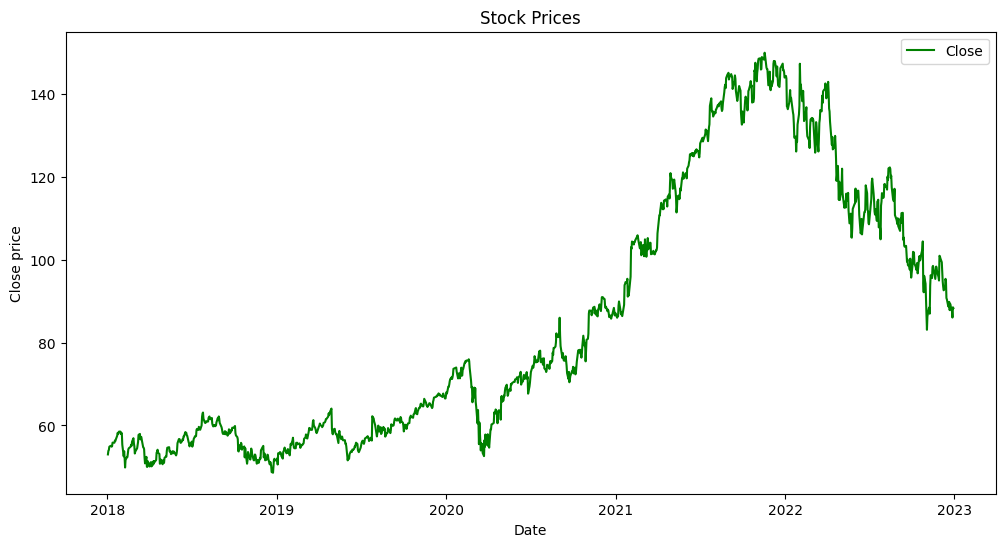

In [7]:
columns=['Close']
show_plt(stock_raw_data, columns)

# 3. Prepare training datasets

In [8]:
def calculate_rsi(df, periods=14):
    delta = df.Close.diff()
    gains = delta.where(delta > 0, 0)
    losses = -delta.where(delta < 0, 0)
    avg_gains = gains.rolling(window=periods).mean()
    avg_losses = losses.rolling(window=periods).mean()
    rs = avg_gains / avg_losses
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_willr(high, low, close, periods=7):
    highest_high = high.rolling(window=periods).max()
    lowest_low = low.rolling(window=periods).min()
    willr = ((highest_high - close) / (highest_high - lowest_low)) * -100
    return willr

In [9]:
def predictor_variables(df):
    df['O-C'] = df.Open - df.Close
    df['H-L'] = df.High - df.Low

    df['3day MA'] = df.Close.shift(1).rolling(window=3).mean()
    df['10day MA'] = df.Close.shift(1).rolling(window=10).mean()
    df['30day MA'] = df.Close.shift(1).rolling(window=30).mean()
    df['Std_dev'] = df.Close.rolling(5).std()

    df['RSI'] = calculate_rsi(df, 14)
    df['Williams %R'] = calculate_willr(df.High, df.Low, df.Close, 7)

    df['Price_Rise'] = np.where(df.Close.shift(-1) > df.Close, 1, 0)
    df = df.dropna()

    return df

In [10]:
stock_df = stock_raw_data.dropna().copy()
stock_df = predictor_variables(stock_raw_data)

In [11]:
stock_df.head()

Price,Open,Close,Low,High,O-C,H-L,3day MA,10day MA,30day MA,Std_dev,RSI,Williams %R,Price_Rise
Ticker,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,
2018-02-14,52.200253,53.232864,52.090775,53.333386,-1.032611,1.242611,52.116819,53.635260,55.328108,1.274271,33.766561,-13.539645,1
2018-02-15,53.699153,54.219193,52.966125,54.316681,-0.520040,1.350556,52.646310,53.136423,55.335905,0.991048,36.696256,-1.980408,1
2018-02-16,54.163955,54.481949,54.159126,54.973122,-0.317994,0.813997,53.269690,52.747366,55.347582,1.004493,37.739804,-8.803849,1
2018-02-20,54.271445,54.863144,54.169427,55.434933,-0.591699,1.265506,53.978002,52.662268,55.361516,1.021047,40.586089,-9.465317,1
2018-02-21,55.062698,55.305050,55.055731,56.431216,-0.242352,1.375485,54.521428,52.894468,55.361898,0.779926,41.062713,-24.322350,0


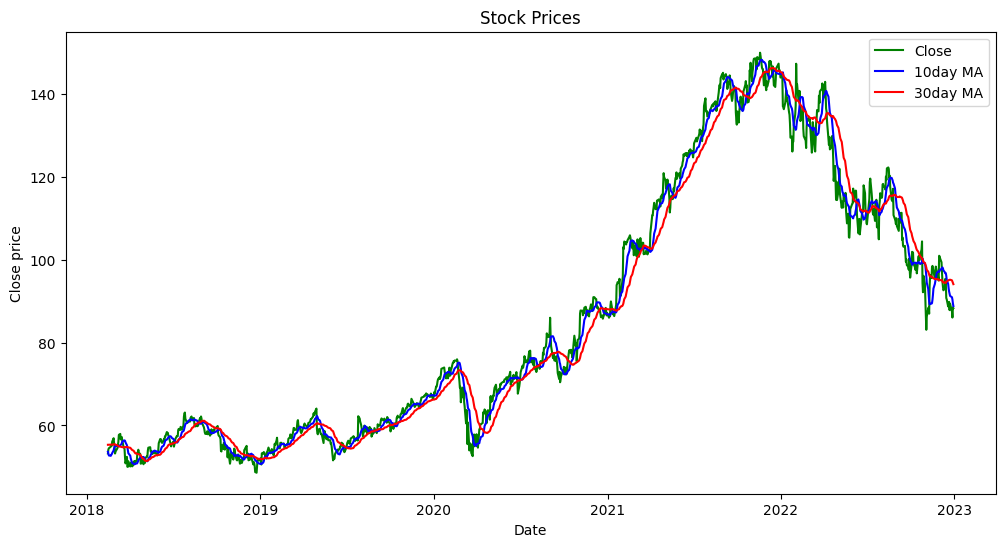

In [12]:
columns=['Close','10day MA','30day MA']
show_plt(stock_df, columns)

In [13]:
stock_df.shape

(1229, 13)

# 4.1. Functions for Machine learning model

In [14]:
def select_columns(df):
    dataX = df.iloc[:, 4:-1].to_numpy()
    dataY = df.iloc[:, -1].to_numpy()
    return dataX, dataY

In [15]:
def normalize(trainX, testX):
    sc = StandardScaler()
    trainX = sc.fit_transform(trainX)
    testX = sc.fit_transform(testX)
    return trainX, testX

In [16]:
# plot diagnostic learning curves
def summarize_diagnostics(history):
    plt.subplot(2, 1, 1)
    plt.title('Cross Entropy Loss')
    plt.plot(history.history['loss'], label='Test')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(2, 1, 2)
    plt.title('Classification Accuracy')
    plt.plot(history.history['accuracy'], label='Test')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.tight_layout()
    plt.legend()
    plt.show()

In [30]:
def define_model():
    model = Sequential()
    model.add(Dense(units=32, activation='relu', kernel_initializer='he_uniform', input_dim=8))
    model.add(Dense(units=32, activation='relu', kernel_initializer='he_uniform'))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    opt = SGD(learning_rate=0.25)
    return model

In [18]:
def define_weak_relu_model():
    model = Sequential()
    model.add(Dense(units=32, kernel_initializer='he_uniform', input_dim=8))
    model.add(LeakyReLU(alpha=0.05))
    model.add(Dense(units=32, kernel_initializer='he_uniform'))
    model.add(LeakyReLU(alpha=0.05))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    opt = SGD(learning_rate=0.25)
    return model

In [19]:
def evaluate_model(df, model):
    dataX, dataY = select_columns(df)

    split = int(len(df)*0.8)
    trainX, testX, trainY, testY = dataX[:split], dataX[split:], dataY[:split], dataY[split:]
    trainX, testX = normalize(trainX, testX)

    history = model.fit(trainX, trainY, epochs=10, batch_size=12, validation_data=(testX, testY), verbose=1)
    _, acc = model.evaluate(testX, testY, verbose=0)
    print('Accurracy = %.3f' % (acc * 100.0))

    return history, model

# 4.2 Model training and Performance

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4863 - loss: 0.8048 - val_accuracy: 0.4756 - val_loss: 0.7395
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5471 - loss: 0.7049 - val_accuracy: 0.4919 - val_loss: 0.7341
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5383 - loss: 0.7022 - val_accuracy: 0.4634 - val_loss: 0.7408
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5955 - loss: 0.6779 - val_accuracy: 0.4715 - val_loss: 0.7302
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5819 - loss: 0.6729 - val_accuracy: 0.4715 - val_loss: 0.7345
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5780 - loss: 0.6823 - val_accuracy: 0.4634 - val_loss: 0.7279
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5586 - loss: 0.6745 - val_accuracy: 0.4675 - val_loss: 0.7263
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6074 - loss: 0.6680 - val_accuracy: 0.4837 - val_loss:

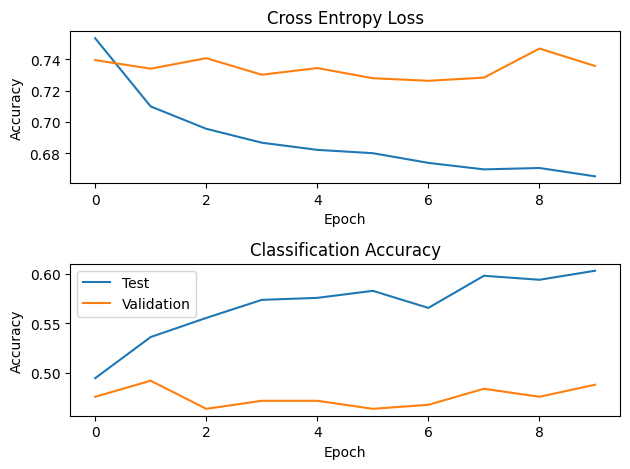

In [31]:
history1, model1 = evaluate_model(stock_df, define_model())
summarize_diagnostics(history1)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5255 - loss: 0.8539 - val_accuracy: 0.5285 - val_loss: 0.7070
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5066 - loss: 0.7255 - val_accuracy: 0.5041 - val_loss: 0.7091
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5373 - loss: 0.6926 - val_accuracy: 0.5163 - val_loss: 0.7094
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5590 - loss: 0.6827 - val_accuracy: 0.5772 - val_loss: 0.6903
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5486 - loss: 0.6838 - val_accuracy: 0.5163 - val_loss: 0.7005
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5719 - loss: 0.6730 - val_accuracy: 0.5041 - val_loss: 0.6996
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5863 - loss: 0.6722 - val_accuracy: 0.5244 - val_loss: 0.6943
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5734 - loss: 0.6743 - val_accuracy: 0.5041 - val_loss:

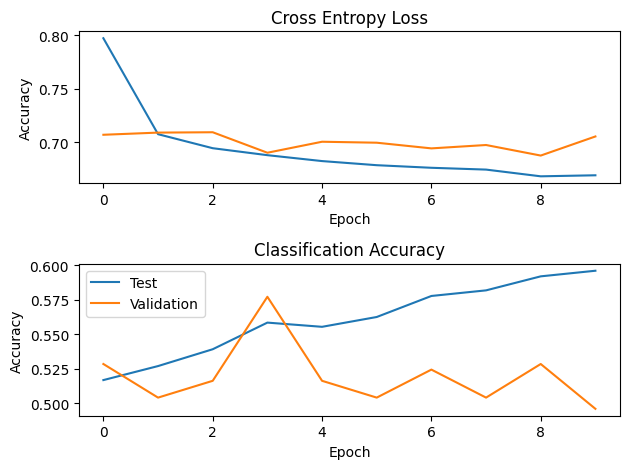

In [21]:
history2, model2 = evaluate_model(stock_df, define_weak_relu_model())
summarize_diagnostics(history2)

# 5. Apply model in google stonk

In [22]:
def run_model(df, model):
    dataX, dataY = select_columns(df)
    y_pred = model.predict(dataX)
    y_pred = (y_pred > 0.5)
    df['y_pred'] = np.nan
    df.iloc[(len(df) - len(y_pred)):,-1:] = y_pred.astype(np.float64)
    trade_df = df.dropna()
    return trade_df

In [23]:
def calculate_returns(trade_df):
    trade_df['Tomorrows Returns'] = np.log(trade_df['Close']/trade_df['Close'].shift(1))
    trade_df['Tomorrows Returns'] = trade_df['Tomorrows Returns'].shift(-1)

    trade_df['Strategy Returns'] = 0.
    trade_df['Strategy Returns'] = np.where(trade_df['y_pred'] == True, trade_df['Tomorrows Returns'], - trade_df['Tomorrows Returns'])

    trade_df.loc[:, 'Cumulative Market Returns'] = np.cumsum(trade_df['Tomorrows Returns'])
    trade_df.loc[:, 'Cumulative Strategy Returns'] = np.cumsum(trade_df['Strategy Returns'])

    trade_df = trade_df.dropna()
    return trade_df

In [32]:
stock_df_test_data = yf_stock('GOOG', start_date='2020-01-01', end_date='2024-12-31')
stock_df_test_data = predictor_variables(stock_df_test_data)

[*********************100%***********************]  1 of 1 completed


In [33]:
trade_df1 = stock_df_test_data.dropna().copy()
trade_df1 = run_model(trade_df1, model1)
trade_df1 = calculate_returns(trade_df1)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


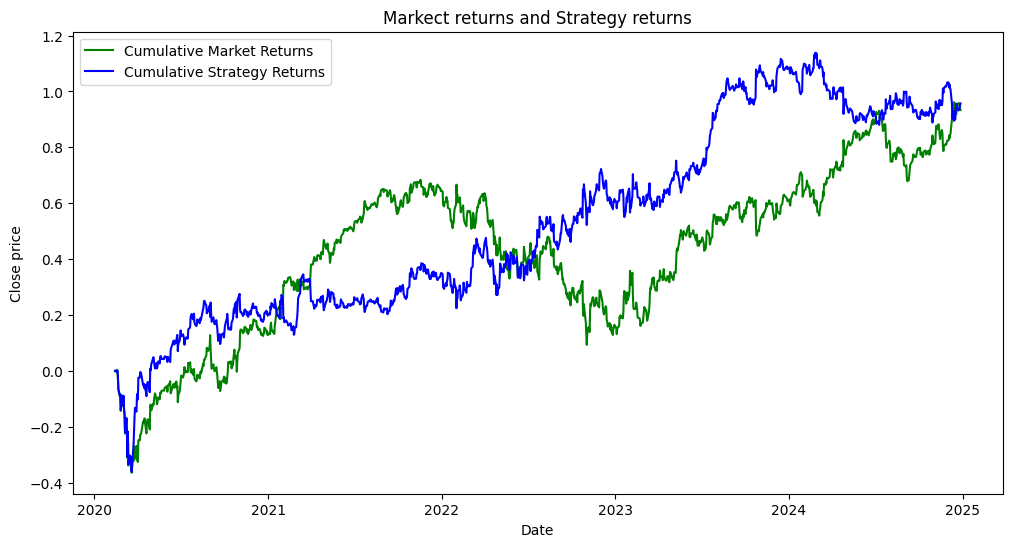

In [34]:
columns = ['Cumulative Market Returns', 'Cumulative Strategy Returns']
show_plt(trade_df1, columns, "Markect returns and Strategy returns")

In [28]:
trade_df2 = stock_df_test_data.dropna().copy()
trade_df2 = run_model(trade_df2, model2)
trade_df2 = calculate_returns(trade_df2)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


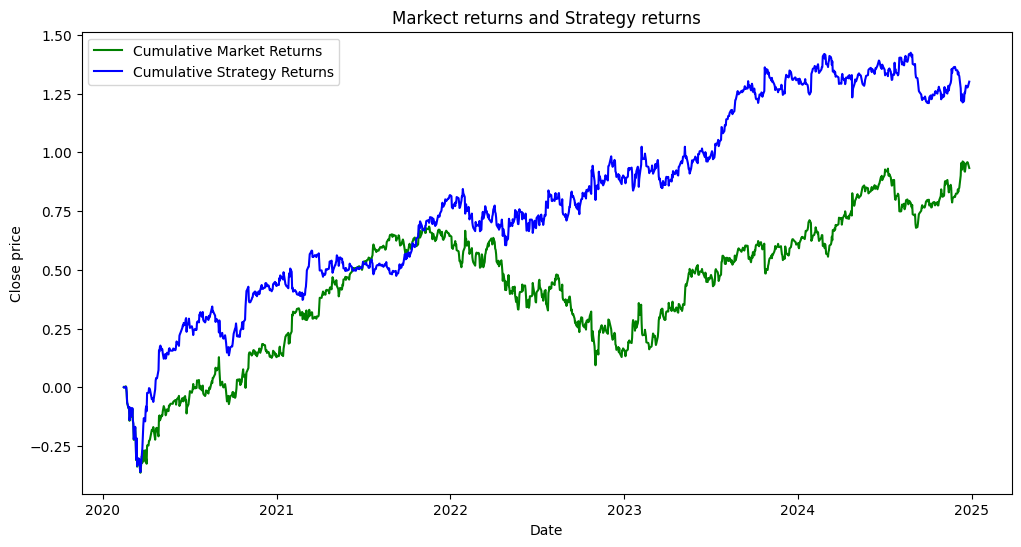

In [35]:
columns = ['Cumulative Market Returns', 'Cumulative Strategy Returns']
show_plt(trade_df2, columns, "Markect returns and Strategy returns")